## 문제: 1차 상미분 방정식 풀기 (Forward Euler, RK4 방법 적용하여 비교)

위에서 Forward Euler 방법으로 풀었던 다음 1차 상미분 방정식(ODE)을 이번에는 RK4(Runge-Kutta 4th order) 방법을 사용하여 $t=0$ 부터 $t=10$ 까지의 시간 범위에서 $y(t)$ 값을 예측하는 코드를 PyTorch로 작성합니다.

$$\frac{dy}{dt} = -0.5y$$

초기 조건 $y(0) = 1$, 최종 시간 $t_{end} = 10$, 시간 간격 $\Delta t = 0.1$, 초기 조건 $y(0) = 1$, 상수 $k = 0.5$ 입니다.

**해석적 해:**
이 ODE의 해석적 해는 $y(t) = e^{-0.5t}$ 입니다. RK4 방법으로 얻은 결과와 비교해보세요.

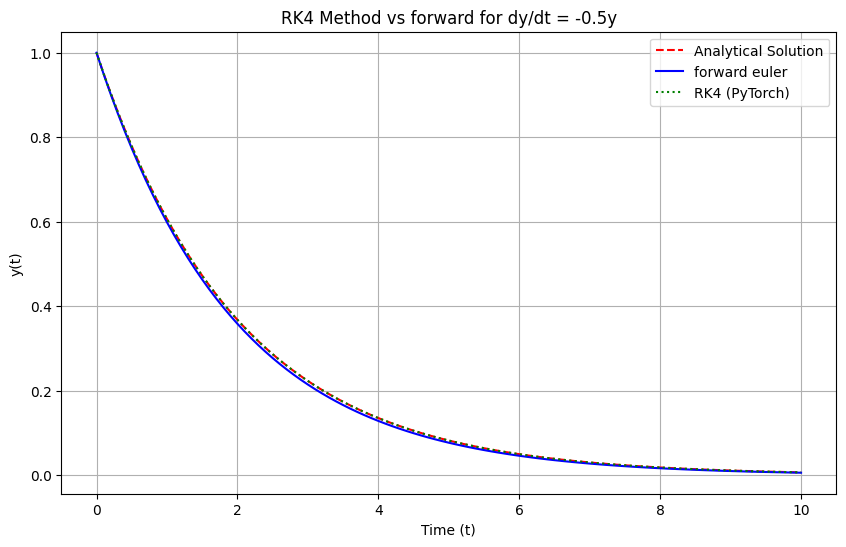

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. ODE 함수 정의: dy/dt = -k * y
def ode_function(y, t, k):
    return -k * y

# 2. 파라미터 설정
k = 0.5
y0 = torch.tensor(1.0)  # 초기 조건
t0 = 0.0
t_end = 10.0
dt = 0.1  # 시간 간격 (문제 명시된 값으로 설정)

# 시간 스텝 수 계산
num_steps = int((t_end - t0) / dt)

# 결과를 저장할 리스트 초기화
t_values = [t0]

y_rk4 = [y0.item()] #rk_4에 의한 추정 y
y_fw = [y0.item()]  #forward euler에 의한 추정 y

# RK4, forward 방법 구현
y_current_rk = y0
t_current = t0

y_current_fw = y0

for i in range(num_steps):
    # RK4 스텝 계산
    k1 = ode_function(y_current_rk, t_current, k)
    k2 = ode_function(y_current_rk + 0.5 * k1*dt, t_current + 0.5 * dt, k)
    k3 = ode_function(y_current_rk + 0.5 * k2*dt, t_current + 0.5 * dt, k)
    k4 = ode_function(y_current_rk + k3*dt, t_current + dt, k)

    # 다음 y_next_rk 값 업데이트
    y_next_rk = y_current_rk + dt*((k1 + 2*k2 + 2*k3 + k4) / 6)

    # 다음 y_next_fw 값 업데이트
    y_next_fw = y_current_fw + ode_function(y_current_fw, t_current, k)*dt


    # 시간 업데이트
    t_next = t_current + dt

    # 결과 저장
    t_values.append(t_next)
    y_rk4.append(y_next_rk.item())
    y_fw.append(y_next_fw.item())

    # 다음 스텝을 위해 값 업데이트
    y_current_rk = y_next_rk
    y_current_fw = y_next_fw
    t_current = t_next

# 3. 결과 시각화

# 해석적 해 계산
t_analytical = np.linspace(t0, t_end, 100000)
y_analytical = np.exp(-k * t_analytical)

plt.figure(figsize=(10, 6))
plt.plot(t_analytical, y_analytical, label='Analytical Solution', color='red', linestyle='--')
plt.plot(t_values, y_fw, label = 'forward euler', color = 'blue', linewidth = 1.5)
plt.plot(t_values, y_rk4, label='RK4 (PyTorch)', color='green', linewidth = 1.5, linestyle=':')


plt.title('RK4 Method vs forward for dy/dt = -0.5y')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()